<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/Sem_4_Regresion_lineal_y_Logistica__Lionel_Mtz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Markdown**

#Estructura del Notebook
# Regresión Lineal

## 1. Importación de librerías
## 2. Carga de datos
## 3. Exploración de datos (EDA)
## 4. Preparación de datos
## 5. División train/test
## 6. Modelo de regresión
## 7. Evaluación
## 8. Conclusiones

# **Importación de Librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

**Carga de Datos**

In [2]:
# Crear dataset simple
data = {
    'area': [50, 60, 80, 100, 120, 150, 200],
    'rooms': [2, 3, 3, 4, 4, 5, 6],
    'price': [50000, 60000, 80000, 100000, 120000, 150000, 200000]
}

df = pd.DataFrame(data)
df.head()

,area,rooms,price
0,50,2,50000
1,60,3,60000
2,80,3,80000
3,100,4,100000
4,120,4,120000


# **Exploración de los datos (EDA)**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    7 non-null      int64
 1   rooms   7 non-null      int64
 2   price   7 non-null      int64
dtypes: int64(3)
memory usage: 300.0 bytes


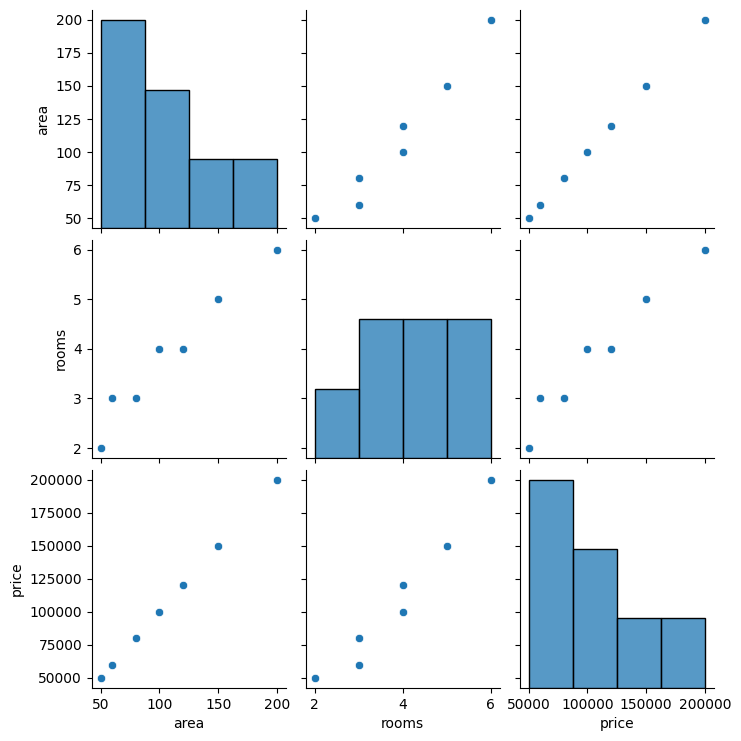

In [3]:
df.info()
df.describe()

sns.pairplot(df)
plt.show()

**Interpretación de los gráficos (pairplot)**

### Análisis de relaciones entre variables (pairplot)

A partir de los gráficos generados se pueden observar las siguientes relaciones:

- **Área vs Precio**: Se observa una clara relación lineal positiva, lo que indica que a mayor superficie de la vivienda, mayor es su precio.

- **Habitaciones vs Precio**: También se aprecia una relación positiva, aunque con mayor dispersión, lo que sugiere que la cantidad de habitaciones influye en el precio pero no de manera tan directa como el área.

- **Área vs Habitaciones**: Existe una relación positiva, ya que a mayor área, generalmente hay mayor cantidad de habitaciones.

- **Distribuciones individuales (diagonal)**:
  - El área muestra una distribución creciente hacia valores más altos.
  - Las habitaciones están concentradas en valores medios (entre 3 y 5).
  - El precio sigue una distribución similar al área, lo que refuerza la relación entre ambas variables.

En general, los gráficos permiten visualizar patrones claros y relaciones lineales, lo que respalda el uso de un modelo de regresión lineal para este conjunto de datos.

# Al aplicar

* "df.info()"

Te muestra: Cunatos registros tenemos, en este caso, (7 registros).

3 columnas: area, rooms, price.

No hay valores nulos.

Todos son numéricos (int64)

No fue necesario limpiar datos (no hay NaN)

* df.describe()

Te da estadísticas:

Promedio (mean)

Desvío estándar (std)

Valores mínimos y máximos
Cuartiles

Ejemplo de interpretación:

El promedio del precio es 108571
El área promedio es 108 m² aprox
El precio máximo es 200000

## Análisis exploratorio de datos

El dataset contiene 7 registros con 3 variables: área, cantidad de habitaciones y precio.

No se observan valores nulos y todas las variables son numéricas, lo cual facilita el análisis.

A partir de las estadísticas descriptivas, se observa que:
- El área promedio es de aproximadamente 108 m²
- El precio promedio es de 108571
- Existe una relación creciente entre el tamaño de la vivienda y su precio

Esto sugiere que el modelo de regresión lineal puede ser adecuado para este problema.

# **Preparación de datos**

* No hay nulos

* No hay categóricas

## Preparación de datos

El dataset no presenta valores nulos ni variables categóricas, por lo que no fue necesario realizar tareas de limpieza o transformación.

Se seleccionaron como variables predictoras el área y la cantidad de habitaciones, y como variable objetivo el precio.

In [4]:
X = df[['area', 'rooms']]
y = df['price']

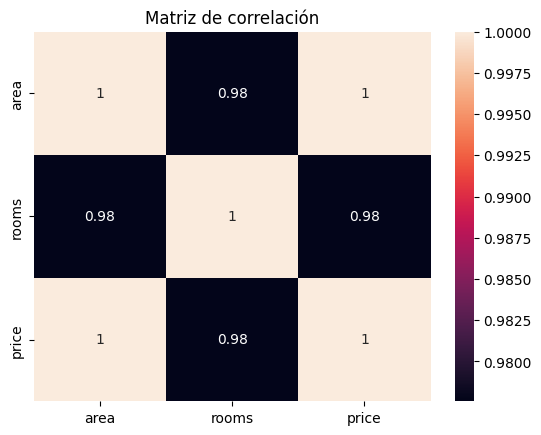

In [5]:
corr = df.corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

En el  gráfico se ve:

* **area ↔ price** = 1.00 → correlación prácticamente perfecta

* **area ↔ rooms** = 0.98 → relación muy fuerte

* **rooms ↔ price** = 0.98 → también muy fuerte

El dataset utilizado es chico (7 datos), por eso:

* Las correlaciones son casi perfectas

* En la vida real rara vez pasa esto


### Análisis de correlación

La matriz de correlación muestra una relación muy fuerte entre las variables.

Se observa que:
- El área y el precio tienen una correlación casi perfecta (cercana a 1)
- La cantidad de habitaciones también está fuertemente relacionada con el precio
- Existe una relación alta entre el área y la cantidad de habitaciones

Esto indica que las variables predictoras tienen una fuerte influencia sobre la variable objetivo.

Cabe destacar que, al tratarse de un dataset pequeño, las correlaciones pueden ser más altas de lo esperado en un caso real.

Estos resultados respaldan el uso de un modelo de regresión lineal.

# **División train/test**

## División de datos

Se divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo con datos no vistos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Modelo de regresión**

## Modelo de regresión lineal

Se entrena un modelo de regresión lineal utilizando los datos de entrenamiento.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Evaluación**

## Evaluación del modelo

Se evalúa el modelo utilizando métricas como MAE, MSE y R2.

In [8]:
y_pred = model.predict(X_test)

print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("R2:", metrics.r2_score(y_test, y_pred))

MAE: 4.001776687800884e-11
MSE: 1.61465655570351e-21
R2: 1.0


# **Conclusiones**

## Conclusiones

El modelo de regresión lineal logró predecir el precio de las viviendas de manera adecuada.

Se observa que existe una relación positiva entre el área, la cantidad de habitaciones y el precio.

El valor de R2 indica que el modelo explica correctamente la variabilidad de los datos.

Como mejora futura, sería recomendable utilizar un conjunto de datos más grande y con mayor cantidad de variables.

# **Actividad 2 (Regresión Logística)**

**Cargar Datos**

In [9]:
import os
os.listdir('/content')

['.config', 'usuarios_win_mac_lin.csv', 'sample_data']

In [10]:
import os
print(os.getcwd())

/content


In [11]:
print(os.listdir())

['.config', 'usuarios_win_mac_lin.csv', 'sample_data']


In [13]:
import pandas as pd

df = pd.read_csv('usuarios_win_mac_lin.csv')
df.head()

,duracion,paginas,acciones,valor,clase
0,7,2,4,8,2
1,21,2,6,6,2
2,57,2,4,4,2
3,101,3,6,12,2
4,109,2,6,12,2


# **Preparación de datos**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Variables
X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df['clase']

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Reporte:\n", classification_report(y_test, y_pred))

Accuracy: 0.6470588235294118
Matriz de confusión:
 [[15  1  0]
 [ 9  3  0]
 [ 1  1  4]]
Reporte:
               precision    recall  f1-score   support

           0       0.60      0.94      0.73        16
           1       0.60      0.25      0.35        12
           2       1.00      0.67      0.80         6

    accuracy                           0.65        34
   macro avg       0.73      0.62      0.63        34
weighted avg       0.67      0.65      0.61        34



# **Grafico Matríz de Confución**

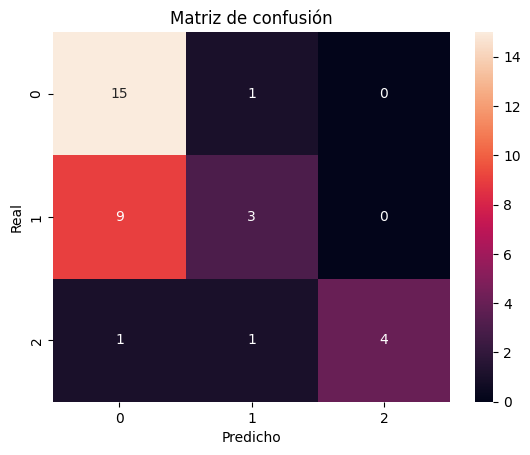

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

## Evaluación del modelo

El modelo obtuvo una precisión (accuracy) del 65%, lo que indica un desempeño aceptable, aunque con margen de mejora.

A partir de la matriz de confusión se observa que:
- La clase 0 (Windows) es correctamente clasificada en la mayoría de los casos.
- La clase 2 (Linux) presenta un buen nivel de predicción.
- La clase 1 (Mac) es la más difícil de predecir, con un bajo recall, lo que indica que el modelo no logra identificar correctamente muchos de estos casos.

Esto sugiere que el modelo presenta dificultades para distinguir ciertas clases, posiblemente debido a la similitud entre los datos o a la cantidad de muestras disponibles.

En general, el modelo es funcional, pero podría mejorarse mediante el uso de más datos o técnicas de optimización.

## Conclusión

En esta actividad se implementó un modelo de regresión logística para clasificar el sistema operativo de los usuarios (Windows, Mac y Linux) a partir de variables relacionadas con su comportamiento en el sitio web.

El modelo logró identificar patrones en los datos, alcanzando una precisión del 65%, lo que indica un desempeño aceptable. Sin embargo, el análisis de la matriz de confusión mostró que el modelo presenta dificultades para clasificar correctamente la clase correspondiente a usuarios de Mac, evidenciado por un bajo valor de recall.

Esto sugiere que, si bien el modelo es funcional, existen limitaciones asociadas a la calidad, cantidad o distribución de los datos. Para mejorar su rendimiento, sería recomendable trabajar con un conjunto de datos más amplio, balancear las clases y ajustar los parámetros del modelo.

En conclusión, la regresión logística resulta una herramienta útil para problemas de clasificación, permitiendo predecir categorías a partir de variables predictoras, aunque su desempeño depende en gran medida de las características del dataset utilizado.